### **Neural Network non-convex optimization**

In this notebook, we will use a trained gradient descent model with adaptive learning rate to optimize LeNet-5 on the MNIST task.

In [1]:
import gymnasium as gym
import seaborn as sns
import matplotlib.pyplot as plt
import src.gymnasium_envs.nn_optimization_env

from stable_baselines3 import PPO
from stable_baselines3.common.env_util import make_vec_env
from stable_baselines3.common.vec_env import VecNormalize, VecFrameStack

import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.datasets as datasets
from torch.utils.data import TensorDataset, DataLoader

import copy
import itertools

from src.nn_models.lenet import LeNet

seed = 100

We set up an environment with a particular seed and load the model.

In [2]:
env = make_vec_env(
    "nn_optimization_env/NeuralNetworkOptimization-v0", 
    n_envs=1,
    seed=seed,
    env_kwargs={
        "dataset_name": "MNIST"
    }
)


env = VecNormalize.load("../models/lenet_mnist_convex_optimization_vec_normalize_stats.pkl", env)

env.training = False
env.norm_reward = False 

env = VecFrameStack(env, n_stack=10)

model = PPO.load("../models/lenet_mnist_optimization", env=env, seed=seed)

obs = env.reset()

rl_gd_info = []

c:\Users\Lolik\Documents\GitHub\Reinforcement-learning-for-Gradient-descent\venv\Lib\site-packages\gymnasium\envs\registration.py:728: UserWarning: WARN: The environment is being initialised with render_mode='rgb_array' that is not in the possible render_modes ([None]).
  logger.warn(


We will use one dict to store all optimization experiments

In [3]:
results = {
    'Adaptive LR Model' : []
}

Let's conduct a training cycle with adaptive learning rate model.

In [4]:
done = False

while not done:
    action, _states = model.predict(obs, deterministic=True)
    
    obs, reward, terminated, info = env.step(action)
    
    results['Adaptive LR Model'].append(info[0]['loss'])

    done = terminated

Now we can run a training cycle for the standard ADAM and SGD gradient descents. We use the same neural network with the same seed.

In [5]:
train_dataset = datasets.MNIST(root='./data', train=True, download=True)
test_dataset = datasets.MNIST(root='./data', train=False, download=True)

X_train = train_dataset.data.unsqueeze(1).float() / 255.0
y_train = train_dataset.targets.long()

X_test = test_dataset.data.unsqueeze(1).float() / 255.0
y_test = test_dataset.targets.long()

train_ds = TensorDataset(X_train, y_train)
test_ds = TensorDataset(X_test, y_test)

In [6]:
experiments = {
    'SGD'       : {'class': torch.optim.SGD, 'params': {'lr': 0.01, 'momentum': 0.9}},
    'Adam'      : {'class': torch.optim.Adam, 'params': {'lr': 0.001}},
    'AdamW'     : {'class': torch.optim.AdamW, 'params': {'lr': 0.001, 'weight_decay': 0.01}}
}

base_nn_model = LeNet(seed=seed)
initial_state = copy.deepcopy(base_nn_model.state_dict())

iteration_count = 10000 

for name, config in experiments.items():
    print(f"Starting optimization with {name}")

    results.setdefault(name, [])
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    nn_model = LeNet(seed=seed)
    nn_model.load_state_dict(initial_state)

    nn_model.to(device)
    optimizer = config['class'](nn_model.parameters(), **config['params'])
    criterion = nn.CrossEntropyLoss()

    g = torch.Generator()
    g.manual_seed(seed)

    train_loader = DataLoader(train_ds, batch_size=256, shuffle=True, generator=g)
    train_loader = itertools.cycle(train_loader)

    for i in range(iteration_count):

        inputs, labels = next(train_loader)
        inputs, labels = inputs.to(device), labels.to(device)

        optimizer.zero_grad()

        outputs = nn_model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()

        loss_value = loss.item()

        if i % 100 == 0:
            print(f"Method: {name} | Iteration: {i} | Loss: {loss_value}")

        results[name].append(loss_value)

        optimizer.step()

Starting optimization with SGD
Method: SGD | Iteration: 0 | Loss: 2.740762948989868
Method: SGD | Iteration: 100 | Loss: 2.3095269203186035
Method: SGD | Iteration: 200 | Loss: 2.3068172931671143
Method: SGD | Iteration: 300 | Loss: 2.3035295009613037
Method: SGD | Iteration: 400 | Loss: 2.289578437805176
Method: SGD | Iteration: 500 | Loss: 2.3094241619110107
Method: SGD | Iteration: 600 | Loss: 2.295999765396118
Method: SGD | Iteration: 700 | Loss: 2.3060858249664307
Method: SGD | Iteration: 800 | Loss: 2.3013062477111816
Method: SGD | Iteration: 900 | Loss: 2.3058106899261475
Method: SGD | Iteration: 1000 | Loss: 2.3100030422210693
Method: SGD | Iteration: 1100 | Loss: 2.3098490238189697
Method: SGD | Iteration: 1200 | Loss: 2.30698823928833
Method: SGD | Iteration: 1300 | Loss: 2.2932348251342773
Method: SGD | Iteration: 1400 | Loss: 2.3070638179779053
Method: SGD | Iteration: 1500 | Loss: 2.302736759185791
Method: SGD | Iteration: 1600 | Loss: 2.3021342754364014
Method: SGD | Iter

Lets visualize methods convergence

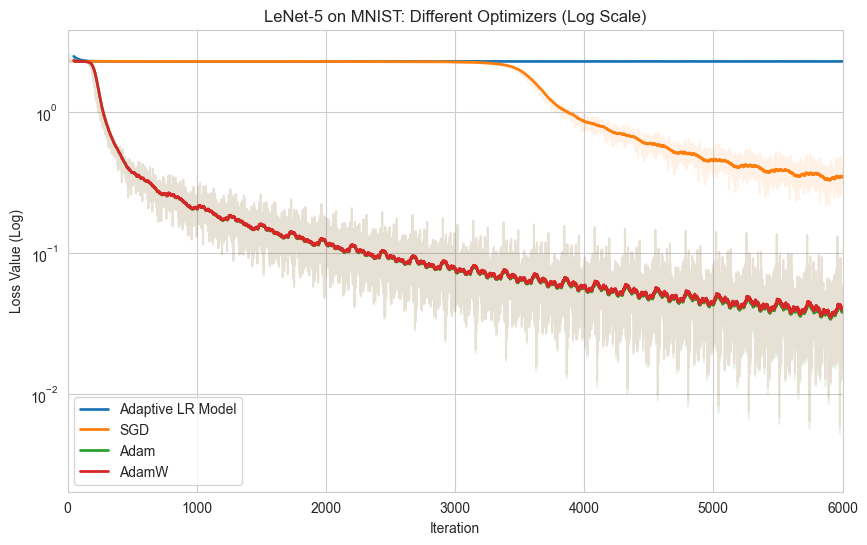

In [7]:
import pandas as pd

plt.figure(figsize=(10, 6))
sns.set_style("whitegrid")

window_size = 50

for name, values in results.items():
    # Превращаем в Series для скользящего среднего
    series = pd.Series(values)
    smoothed = series.rolling(window=window_size).mean()
    
    # Рисуем оригинал полупрозрачным, а сглаженную линию — яркой
    line, = plt.plot(smoothed, label=name, linewidth=2)
    plt.plot(values, color=line.get_color(), alpha=0.1) # Еле заметный фон

plt.title(f'LeNet-5 on MNIST: Different Optimizers (Log Scale)')
plt.xlabel('Iteration')
plt.ylabel('Loss Value (Log)')
plt.legend()
plt.xlim(0, 6000)
plt.yscale('log')
plt.show()

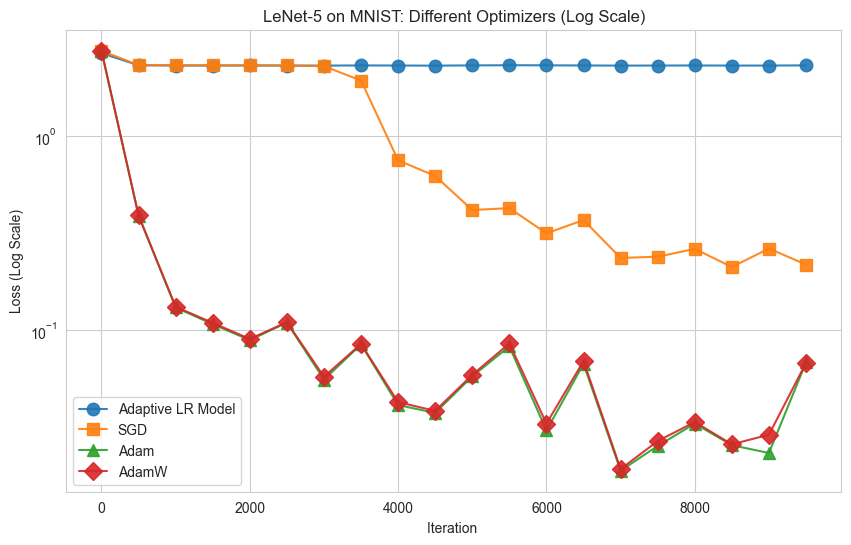

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

plt.figure(figsize=(10, 6))
sns.set_style("whitegrid")
step = 500 

marker_types = ['o', 's', '^', 'D', 'x', 'v', '*']

for i, (name, values) in enumerate(results.items()):
    data = np.array(values)

    sampled_values = data[::step]

    iterations = np.arange(0, len(data), step)
    
    plt.plot(iterations, 
             sampled_values, 
             label=name,
             marker=marker_types[i % len(marker_types)],
             markersize=9,
             linestyle='-',
             linewidth=1.5,
             alpha=0.9)
plt.yscale('log') 

plt.title('LeNet-5 on MNIST: Different Optimizers (Log Scale)')
plt.xlabel(f'Iteration ')
plt.ylabel('Loss (Log Scale)')
plt.legend(loc='best') 

plt.show()